In [1]:
import os
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

# Reproducible project paths. This works when the notebook is run from the
# project root, the notebook folder, or a Colab-style /content directory.
PROJECT_ROOT = Path.cwd()
DATA_CANDIDATES = [
    PROJECT_ROOT / "data" / "insurance.csv",
    PROJECT_ROOT.parent / "data" / "insurance.csv",
    PROJECT_ROOT / "insurance.csv",
    Path("/content/insurance.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "Could not locate insurance.csv. Expected it under data/insurance.csv "
        "relative to the project root or notebook folder."
    )

PLOT_DIR = PROJECT_ROOT / "actuarial_plots"
PLOT_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.facecolor": "#ffffff", "axes.facecolor": "#f8f9fa",
    "axes.edgecolor": "#dee2e6", "axes.labelcolor": "#495057",
    "xtick.color": "#6c757d", "ytick.color": "#6c757d",
    "text.color": "#212529", "grid.color": "#e9ecef",
    "grid.linestyle": "-",
})

PALETTE = ["#003f5c", "#58508d", "#ff6361", "#bc5090"]
RANDOM_STATE = 42



[1/5] INGESTING ACTUARIAL DATA...
  Data source: C:\Users\Baibhab\OneDrive\Desktop\swapnil_project\data\insurance.csv
  Records loaded: 1,337
  Duplicate records removed: 1
  Missing values: 0
  Average Medical Cost: $13,279.12
  Median Medical Cost:  $9,386.16
  Max Medical Cost:     $63,770.43


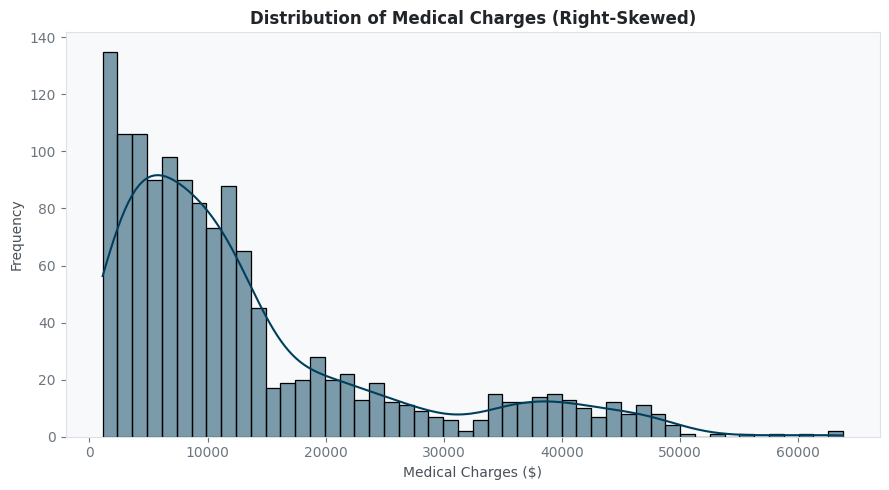

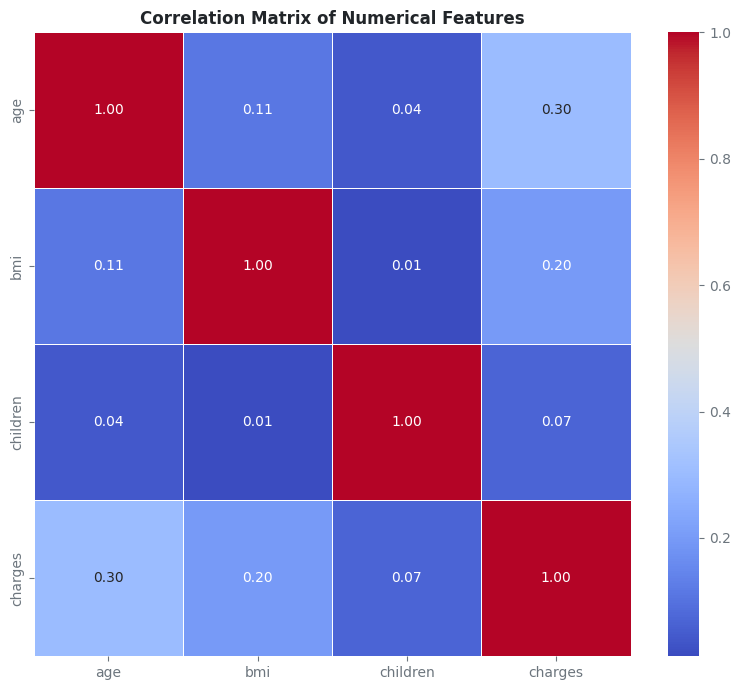

In [2]:
# PHASE 1: DATA INGESTION, CLEANING & EXPLORATION

def resolve_data_path(filepath=None):
    """Resolve a user-supplied path while keeping the notebook portable."""
    if filepath is None:
        return DATA_PATH

    supplied = Path(filepath)
    candidates = [
        supplied,
        PROJECT_ROOT / supplied,
        PROJECT_ROOT.parent / supplied,
        PROJECT_ROOT / "data" / supplied.name,
        PROJECT_ROOT.parent / "data" / supplied.name,
    ]
    match = next((path for path in candidates if path.exists()), None)
    if match is None:
        raise FileNotFoundError(f"Could not locate data file: {filepath}")
    return match


def load_and_explore(filepath=None, remove_duplicates=True):
    print("\n[1/5] INGESTING ACTUARIAL DATA...")
    data_path = resolve_data_path(filepath)
    df = pd.read_csv(data_path)

    duplicate_count = int(df.duplicated().sum())
    if remove_duplicates and duplicate_count:
        df = df.drop_duplicates().reset_index(drop=True)

    print(f"  Data source: {data_path}")
    print(f"  Records loaded: {len(df):,}")
    print(f"  Duplicate records removed: {duplicate_count:,}")
    print(f"  Missing values: {int(df.isna().sum().sum()):,}")
    print(f"  Average Medical Cost: ${df['charges'].mean():,.2f}")
    print(f"  Median Medical Cost:  ${df['charges'].median():,.2f}")
    print(f"  Max Medical Cost:     ${df['charges'].max():,.2f}")

    plt.figure(figsize=(9, 5))
    sns.histplot(df["charges"], bins=50, color=PALETTE[0], kde=True)
    plt.title("Distribution of Medical Charges (Right-Skewed)", fontweight="bold")
    plt.xlabel("Medical Charges ($)")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig(PLOT_DIR / "01_cost_distribution.png", dpi=150)
    plt.show()
    plt.close()

    numerical_cols = ["age", "bmi", "children", "charges"]
    corr_matrix = df[numerical_cols].corr()

    plt.figure(figsize=(8, 7))
    sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=.5)
    plt.title("Correlation Matrix of Numerical Features", fontweight="bold")
    plt.tight_layout()
    plt.savefig(PLOT_DIR / "01_correlation_heatmap.png", dpi=150)
    plt.show()
    plt.close()

    return df


df = load_and_explore()


In [3]:
# PHASE 2: FEATURE ENGINEERING & PREPROCESSING

def engineer_features(df):
    print("\n[2/5] ENGINEERING CLINICAL FEATURES...")
    df = df.copy()

    # Convert categorical text to numeric indicators.
    df["smoker_encoded"] = (df["smoker"] == "yes").astype(int)
    df["sex_encoded"] = (df["sex"] == "female").astype(int)

    # One-hot encode region while avoiding perfect multicollinearity.
    df = pd.get_dummies(df, columns=["region"], drop_first=True, dtype=int)

    # BMI >= 30 is classified as obese. The interaction captures the
    # unusually high cost pattern for clients who are both obese and smokers.
    df["is_obese"] = (df["bmi"] >= 30).astype(int)
    df["obese_smoker_risk"] = df["is_obese"] * df["smoker_encoded"]

    df = df.drop(["sex", "smoker"], axis=1)

    print("  Engineered smoker, sex, region, obesity, and obese-smoker interaction features.")
    return df


if "df" not in globals():
    df = load_and_explore()

df_engineered = engineer_features(df)
print("\nEngineered DataFrame head:")
print(df_engineered.head())



[2/5] ENGINEERING CLINICAL FEATURES...
  Engineered smoker, sex, region, obesity, and obese-smoker interaction features.

Engineered DataFrame head:
   age     bmi  children      charges  smoker_encoded  sex_encoded  \
0   19  27.900         0  16884.92400               1            1   
1   18  33.770         1   1725.55230               0            0   
2   28  33.000         3   4449.46200               0            0   
3   33  22.705         0  21984.47061               0            0   
4   32  28.880         0   3866.85520               0            0   

   region_northwest  region_southeast  region_southwest  is_obese  \
0                 0                 0                 1         0   
1                 0                 1                 0         1   
2                 0                 1                 0         1   
3                 1                 0                 0         0   
4                 1                 0                 0         0   

   obese_smoke

In [4]:
# PHASE 3: TRAIN / TEST SPLIT

def prepare_modeling_data(df):
    print("\n[3/5] PREPARING MATRICES FOR ALGORITHMS...")

    X = df.drop("charges", axis=1)
    y = df["charges"]
    feature_names = X.columns.tolist()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=RANDOM_STATE
    )

    return X_train, X_test, y_train, y_test, feature_names, X, y


if "df_engineered" not in globals():
    if "df" not in globals():
        df = load_and_explore()
    df_engineered = engineer_features(df)

X_train, X_test, y_train, y_test, feature_names, X_full, y_full = prepare_modeling_data(df_engineered)

print("\nData preparation complete:")
print(f"  X_train shape: {X_train.shape}")
print(f"  X_test shape: {X_test.shape}")
print(f"  y_train shape: {y_train.shape}")
print(f"  y_test shape: {y_test.shape}")



[3/5] PREPARING MATRICES FOR ALGORITHMS...

Data preparation complete:
  X_train shape: (1069, 10)
  X_test shape: (268, 10)
  y_train shape: (1069,)
  y_test shape: (268,)


In [5]:
# PHASE 4: REGRESSION MODELING

def build_candidate_models():
    """Create fresh model pipelines for holdout testing and cross-validation."""
    return {
        "Linear Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LinearRegression()),
        ]),
        "Ridge Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=1.0, random_state=RANDOM_STATE)),
        ]),
        "Lasso Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("model", Lasso(alpha=0.1, random_state=RANDOM_STATE, max_iter=10000)),
        ]),
        "Random Forest": Pipeline([
            ("scaler", StandardScaler()),
            ("model", RandomForestRegressor(
                n_estimators=200,
                max_depth=5,
                random_state=RANDOM_STATE,
                n_jobs=1,
            )),
        ]),
    }


def evaluate_model(model_name, y_true, y_pred, color):
    """Evaluate a model, print metrics, and generate a diagnostics plot."""
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    print(f"\n  [{model_name}]")
    print(f"  R2 Score : {r2:.4f} (Explains {r2 * 100:.1f}% of variance)")
    print(f"  MAE      : ${mae:,.2f} (Average absolute error per client)")
    print(f"  RMSE     : ${rmse:,.2f}")

    limit = max(float(np.max(y_true)), float(np.max(y_pred))) * 1.05
    plt.figure(figsize=(7, 6))
    plt.scatter(y_true, y_pred, alpha=0.5, color=color)
    plt.plot([0, limit], [0, limit], "k--", lw=2, label="Perfect Prediction Line")
    plt.title(f"{model_name}: Actual vs Predicted Costs", fontweight="bold")
    plt.xlabel("Actual Billed Charges ($)")
    plt.ylabel("Model Predicted Charges ($)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f"02_{model_name.replace(' ', '_')}_Diagnostics.png", dpi=150)
    plt.show()
    plt.close()

    return {"r2": r2, "mae": mae, "rmse": rmse}


def cross_validate_candidate_models(X, y):
    cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    rows = []

    for name, model in build_candidate_models().items():
        scores = cross_validate(
            model,
            X,
            y,
            cv=cv,
            scoring=("r2", "neg_mean_absolute_error", "neg_root_mean_squared_error"),
        )
        rows.append({
            "Model": name,
            "cv_r2_mean": scores["test_r2"].mean(),
            "cv_r2_std": scores["test_r2"].std(),
            "cv_mae_mean": -scores["test_neg_mean_absolute_error"].mean(),
            "cv_rmse_mean": -scores["test_neg_root_mean_squared_error"].mean(),
        })

    cv_df = pd.DataFrame(rows).set_index("Model").sort_values("cv_mae_mean")
    return cv_df


def train_models(X_train, X_test, y_train, y_test, feature_names, X_full=None, y_full=None):
    """Train candidate regressors, evaluate them, and select the best final model."""
    print("\n[4/5] TRAINING PREDICTIVE MODELS...")

    model_performance_metrics = {}
    trained_models = {}
    candidate_models = build_candidate_models()

    for i, (model_name, model) in enumerate(candidate_models.items()):
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        model_performance_metrics[model_name] = evaluate_model(
            model_name, y_test, preds, PALETTE[i % len(PALETTE)]
        )
        trained_models[model_name] = model

        if model_name == "Linear Regression":
            coefs = model.named_steps["model"].coef_
            coef_df = pd.DataFrame({"Feature": feature_names, "Impact_Weight": coefs})
            coef_df = coef_df.sort_values(by="Impact_Weight", key=abs, ascending=False)
            print("\n  Linear Regression Coefficients (Top Risk Drivers):")
            for _, row in coef_df.head(5).iterrows():
                print(f"   - {row['Feature']:<20}: ${row['Impact_Weight']:,.2f} per scaled unit")

        if model_name == "Random Forest":
            importances = model.named_steps["model"].feature_importances_
            forest_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

            plt.figure(figsize=(10, 6))
            sns.barplot(x=forest_importances.values, y=forest_importances.index, palette="viridis")
            plt.title("Random Forest Feature Importances", fontweight="bold")
            plt.xlabel("Relative Importance")
            plt.ylabel("Feature")
            plt.tight_layout()
            plt.savefig(PLOT_DIR / "02_RandomForest_Feature_Importances.png", dpi=150)
            plt.show()
            plt.close()

    performance_df = pd.DataFrame.from_dict(model_performance_metrics, orient="index")
    performance_df.index.name = "Model"
    performance_df = performance_df.sort_values("mae")

    print("\n=======================================================")
    print("                 HOLDOUT MODEL SUMMARY                ")
    print("=======================================================")
    print(performance_df.round(4).to_string())
    print("=======================================================")

    cv_df = None
    if X_full is not None and y_full is not None:
        cv_df = cross_validate_candidate_models(X_full, y_full)
        print("\n=======================================================")
        print("              5-FOLD CROSS-VALIDATION SUMMARY         ")
        print("=======================================================")
        print(cv_df.round(4).to_string())
        print("=======================================================")
        best_model_name = cv_df.index[0]
        selection_basis = "lowest 5-fold CV MAE"
    else:
        best_model_name = performance_df.index[0]
        selection_basis = "lowest holdout MAE"

    final_model = build_candidate_models()[best_model_name]
    if X_full is not None and y_full is not None:
        final_model.fit(X_full, y_full)
        print(f"\n  Selected final model: {best_model_name} ({selection_basis}).")
        print("  Refit selected model on all cleaned records for client prediction.")
    else:
        final_model = trained_models[best_model_name]
        print(f"\n  Selected final model: {best_model_name} ({selection_basis}).")

    return final_model, best_model_name, performance_df, cv_df



[4/5] TRAINING PREDICTIVE MODELS...

  [Linear Regression]
  R2 Score : 0.9066 (Explains 90.7% of variance)
  MAE      : $2,368.76 (Average absolute error per client)
  RMSE     : $4,142.31


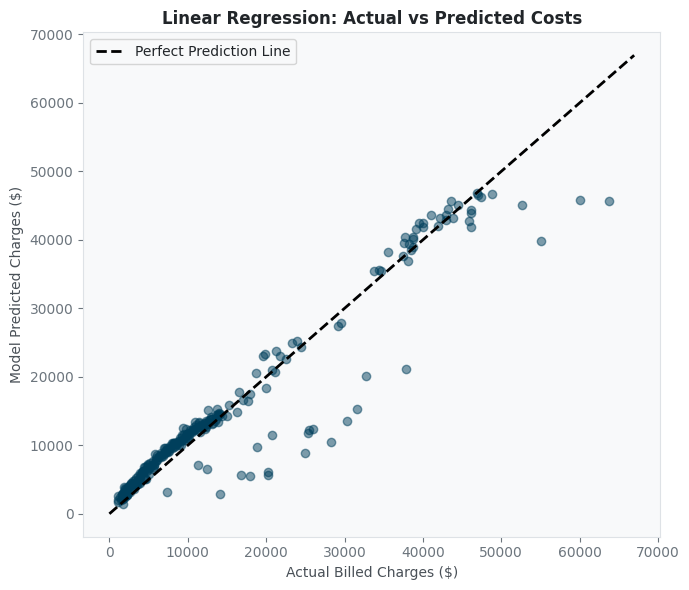


  Linear Regression Coefficients (Top Risk Drivers):
   - obese_smoker_risk   : $5,892.17 per scaled unit
   - smoker_encoded      : $5,284.06 per scaled unit
   - age                 : $3,627.77 per scaled unit
   - children            : $667.81 per scaled unit
   - region_southwest    : $-479.99 per scaled unit

  [Ridge Regression]
  R2 Score : 0.9066 (Explains 90.7% of variance)
  MAE      : $2,370.14 (Average absolute error per client)
  RMSE     : $4,143.62


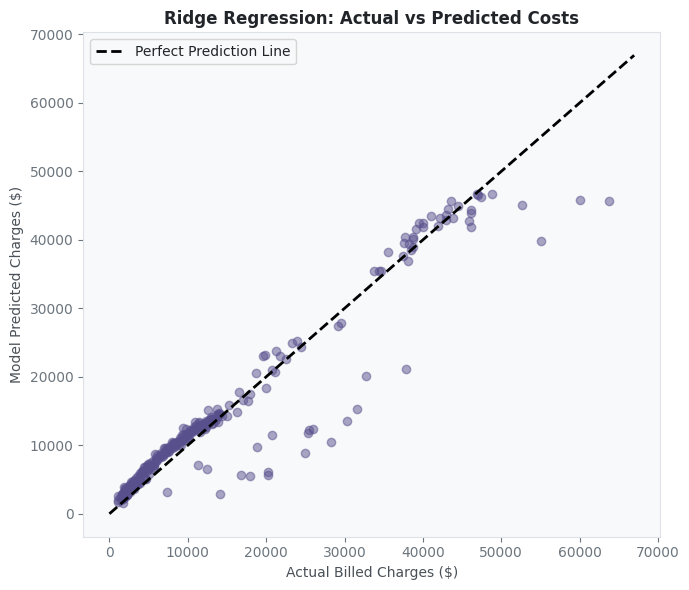


  [Lasso Regression]
  R2 Score : 0.9066 (Explains 90.7% of variance)
  MAE      : $2,368.81 (Average absolute error per client)
  RMSE     : $4,142.41


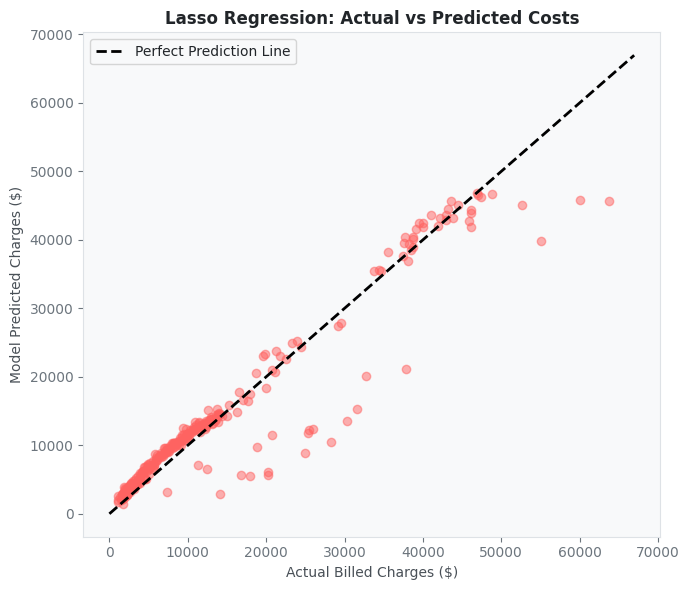


  [Random Forest]
  R2 Score : 0.9029 (Explains 90.3% of variance)
  MAE      : $2,402.72 (Average absolute error per client)
  RMSE     : $4,224.42


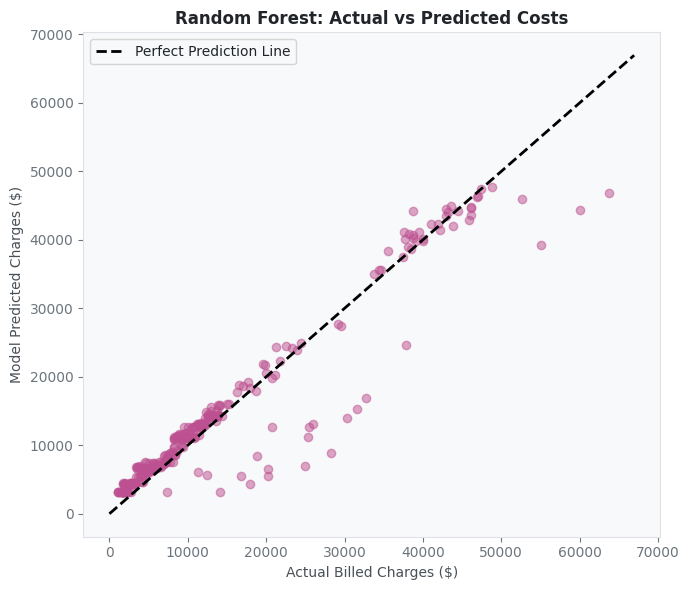

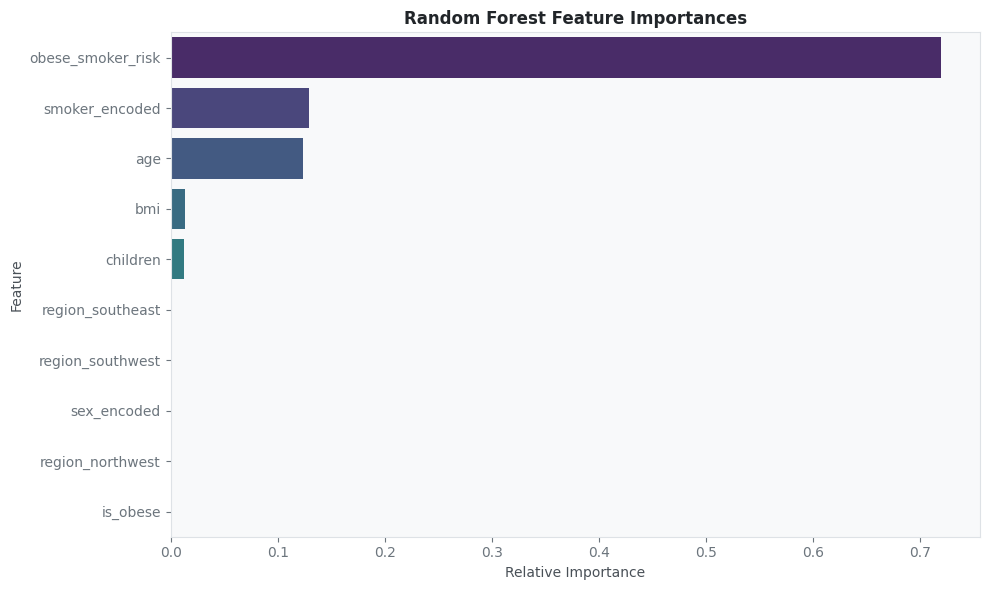


                 HOLDOUT MODEL SUMMARY                
                       r2        mae       rmse
Model                                          
Linear Regression  0.9066  2368.7573  4142.3067
Lasso Regression   0.9066  2368.8131  4142.4068
Ridge Regression   0.9066  2370.1366  4143.6210
Random Forest      0.9029  2402.7219  4224.4239



              5-FOLD CROSS-VALIDATION SUMMARY         
                   cv_r2_mean  cv_r2_std  cv_mae_mean  cv_rmse_mean
Model                                                              
Linear Regression      0.8589     0.0298    2468.3614     4483.7459
Lasso Regression       0.8589     0.0298    2468.3846     4483.7484
Ridge Regression       0.8589     0.0297    2469.2300     4483.7227
Random Forest          0.8564     0.0271    2503.1060     4529.0994

  Selected final model: Linear Regression (lowest 5-fold CV MAE).
  Refit selected model on all cleaned records for client prediction.

[5/5] RUNNING NEW PATIENT SIMULATION...

  PATIENT PROFILE:
  Age: 45 | BMI: 32.5 | Smoker: YES | Dependents: 2
  Model: Linear Regression
-------------------------------------------------------
  ACTUARIAL PREDICTED ANNUAL COST: $42,895.61



In [6]:
# PHASE 5: CLIENT PREDICTION ENGINE

def predict_new_patient(model, feature_names, model_name="Selected Model"):
    print("\n[5/5] RUNNING NEW PATIENT SIMULATION...")

    new_patient = {
        "age": 45,
        "bmi": 32.5,
        "children": 2,
        "smoker_encoded": 1,
        "sex_encoded": 0,
        "region_northwest": 0,
        "region_southeast": 1,
        "region_southwest": 0,
        "is_obese": 1,
        "obese_smoker_risk": 1,
    }

    patient_data = pd.DataFrame([new_patient], columns=feature_names)
    predicted_cost = model.predict(patient_data)[0]

    print("\n=======================================================")
    print("  PATIENT PROFILE:")
    print("  Age: 45 | BMI: 32.5 | Smoker: YES | Dependents: 2")
    print(f"  Model: {model_name}")
    print("-------------------------------------------------------")
    print(f"  ACTUARIAL PREDICTED ANNUAL COST: ${predicted_cost:,.2f}")
    print("=======================================================\n")
    return predicted_cost


if "X_train" not in globals():
    if "df" not in globals():
        df = load_and_explore()
    if "df_engineered" not in globals():
        df_engineered = engineer_features(df)
    X_train, X_test, y_train, y_test, feature_names, X_full, y_full = prepare_modeling_data(df_engineered)

final_model, final_model_name, holdout_metrics, cv_metrics = train_models(
    X_train, X_test, y_train, y_test, feature_names, X_full, y_full
)
predicted_cost = predict_new_patient(final_model, feature_names, final_model_name)
